In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load GloVe 100d
# Set this to your local GloVe file path, e.g. "./glove.6B.100d.txt"
GLOVE_PATH = "../data/glove.6B.100d.txt"

if not os.path.exists(GLOVE_PATH):
    raise FileNotFoundError(f"GloVe file not found at {GLOVE_PATH}. Set GLOVE_PATH to a valid path.")

print("Loading GloVe from", GLOVE_PATH)

word_list = []
vec_list = []
with open(GLOVE_PATH, "r", encoding="utf-8") as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) < 10:
            continue
        w = parts[0]
        v = np.asarray(parts[1:], dtype=np.float32)
        word_list.append(w)
        vec_list.append(v)

V = np.vstack(vec_list)
words = np.array(word_list)
print("Loaded embeddings:", V.shape)

# Normalize embeddings
V_norm = V / np.linalg.norm(V, axis=1, keepdims=True)

Loading GloVe from ../data/glove.6B.100d.txt
Loaded embeddings: (400000, 100)


In [8]:
# 2. Select month and weekday tokens
months = [
    "january","february","march","april","may","june",
    "july","august","september","october","november","december"
]
days = ["monday","tuesday","wednesday","thursday","friday","saturday","sunday"]

idx = {w: i for i, w in enumerate(words)}

months_in_vocab = [w for w in months if w in idx]
days_in_vocab = [w for w in days if w in idx]

print("Months in vocab:", months_in_vocab)
print("Days in vocab:", days_in_vocab)

if len(months_in_vocab) == 0 or len(days_in_vocab) == 0:
    raise RuntimeError("No month/day tokens found in the GloVe vocabulary.")

month_vecs = np.stack([V_norm[idx[w]] for w in months_in_vocab])
day_vecs = np.stack([V_norm[idx[w]] for w in days_in_vocab])

# 3. Shared orthogonal basis via SVD on union of month+day vectors
X_cat = np.vstack([month_vecs, day_vecs])
U, S, Vt = np.linalg.svd(X_cat, full_matrices=False)
A = Vt  # rows: orthonormal axes

# 4. Project all vocab into spectral basis
alpha = V_norm @ A.T
energy = alpha ** 2

# 5. Minkowski coordinates (H,B,M)
k_core = 5  # number of core axes for H

H_vals = np.sum(energy[:, :k_core], axis=1)
B_vals = np.sum(energy[:, k_core:], axis=1)

c = 1.0
M2 = B_vals**2 - (c**2) * (H_vals**2)
M_vals = np.sign(M2) * np.sqrt(np.abs(M2))

mink_df = pd.DataFrame({
    "word": words,
    "H": H_vals,
    "B": B_vals,
    "M": M_vals,
})

# 6. Month/Day centers and funnel axes
month_center = month_vecs.mean(axis=0)
month_center /= np.linalg.norm(month_center)

day_center = day_vecs.mean(axis=0)
day_center /= np.linalg.norm(day_center)

alpha_month_center = month_center @ A.T
alpha_day_center = day_center @ A.T

H_month_center = np.sum(alpha_month_center[:k_core] ** 2)
B_month_center = np.sum(alpha_month_center[k_core:] ** 2)

H_day_center = np.sum(alpha_day_center[:k_core] ** 2)
B_day_center = np.sum(alpha_day_center[k_core:] ** 2)

print("Month center (H,B):", H_month_center, B_month_center)
print("Day center   (H,B):", H_day_center, B_day_center)

axis_month = month_center  # already unit norm
axis_day = day_center

# 7. Funnel depth scores
cos_month = V_norm @ axis_month
cos_day = V_norm @ axis_day

mink_df["cos_month"] = cos_month
mink_df["cos_day"] = cos_day

# depth = alignment * H / (1 + |M|)
mink_df["depth_month"] = mink_df["cos_month"] * mink_df["H"] / (1.0 + np.abs(mink_df["M"]))
mink_df["depth_day"] = mink_df["cos_day"] * mink_df["H"] / (1.0 + np.abs(mink_df["M"]))

seed_set = set(months_in_vocab + days_in_vocab)
mask_non_seed = ~mink_df["word"].isin(seed_set)

K = 50
month_funnel = mink_df[mask_non_seed].nlargest(K, "depth_month")
day_funnel = mink_df[mask_non_seed].nlargest(K, "depth_day")

print("\nTop 20 deep words in Month funnel:")
print(month_funnel[["word", "depth_month", "H", "B", "M"]].head(20).to_markdown())

print("\nTop 20 deep words in Day funnel:")
print(day_funnel[["word", "depth_day", "H", "B", "M"]].head(20).to_markdown())

Months in vocab: ['january', 'february', 'march', 'april', 'may', 'june', 'july', 'august', 'september', 'october', 'november', 'december']
Days in vocab: ['monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday']
Month center (H,B): 0.9999997 1.8214193e-07
Day center   (H,B): 0.9999993 8.466831e-07

Top 20 deep words in Month funnel:
|      | word   |   depth_month |        H |         B |         M |
|-----:|:-------|--------------:|---------:|----------:|----------:|
| 1263 | 29     |      0.352628 | 0.730696 | 0.0323974 | -0.729978 |
| 1076 | 26     |      0.351168 | 0.725536 | 0.0316588 | -0.724845 |
| 1086 | 28     |      0.347796 | 0.717706 | 0.0313515 | -0.717021 |
| 2224 | dec.   |      0.347149 | 0.7475   | 0.0952135 | -0.741411 |
|  952 | 21     |      0.344841 | 0.715165 | 0.0292653 | -0.714566 |
|  229 | month  |      0.344267 | 0.807557 | 0.0469394 | -0.806191 |
| 2698 | aug.   |      0.338501 | 0.742347 | 0.0817015 | -0.737837 |
| 1094 | 27     |     

In [21]:
# 기존: energy = alpha**2
energy = alpha ** 2

# === 새 정의: H = alpha_1, B = alpha_2 ===
H_vals = alpha[:, 0]            # first axis coordinate
B_vals = alpha[:, 1]            # second axis coordinate

# Minkowski metric with constant c
c = 1.0
M2 = B_vals**2 - (c**2) * (H_vals**2)
M_vals = np.sign(M2) * np.sqrt(np.abs(M2))

mink_df = pd.DataFrame({
    "word": words,
    "H": H_vals,
    "B": B_vals,
    "M": M_vals,
})

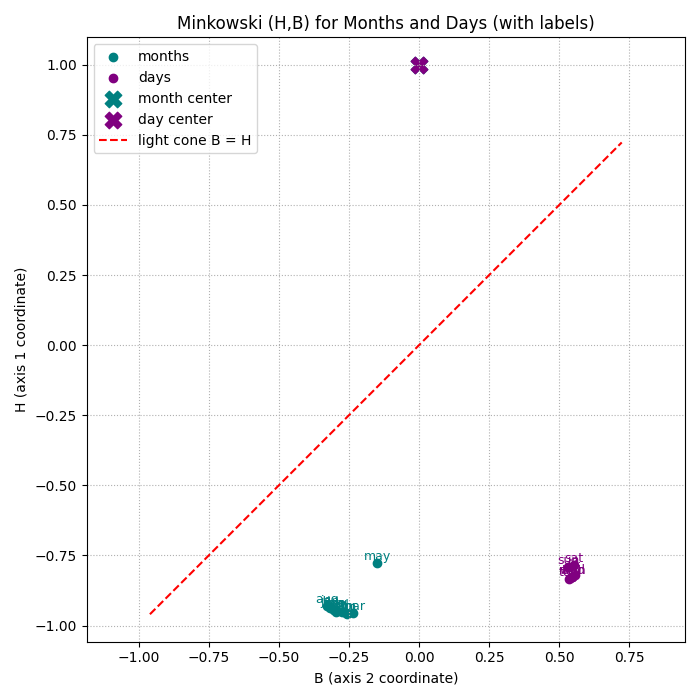

In [34]:
%matplotlib widget
mink_idx = mink_df.set_index("word")

plt.figure(figsize=(7, 7))

# month/day 좌표
B_month = mink_idx.loc[months_in_vocab]["B"]
H_month = mink_idx.loc[months_in_vocab]["H"]
B_day   = mink_idx.loc[days_in_vocab]["B"]
H_day   = mink_idx.loc[days_in_vocab]["H"]

# 산점도
plt.scatter(B_month, H_month, c="teal", label="months")
plt.scatter(B_day,   H_day,   c="purple", label="days")

# 라벨링: month
for w in months_in_vocab:
    x = mink_idx.loc[w, "B"]
    y = mink_idx.loc[w, "H"]
    plt.text(x, y, w[:3], color="teal", fontsize=9,
             ha="center", va="bottom")

# 라벨링: day
for w in days_in_vocab:
    x = mink_idx.loc[w, "B"]
    y = mink_idx.loc[w, "H"]
    plt.text(x, y, w[:3], color="purple", fontsize=9,
             ha="center", va="bottom")

# 센터
plt.scatter(B_month_center, H_month_center,
            c="teal", marker="X", s=140, label="month center")
plt.scatter(B_day_center, H_day_center,
            c="purple", marker="X", s=140, label="day center")

# light cone: B = H
H_line = np.linspace(mink_df["H"].min(), mink_df["H"].max(), 100)
B_line = H_line
plt.plot(B_line, H_line, "r--", label="light cone B = H")

plt.xlabel("B (axis 2 coordinate)")
plt.ylabel("H (axis 1 coordinate)")
plt.title("Minkowski (H,B) for Months and Days (with labels)")
plt.legend(loc="best")
plt.grid(True, linestyle=":")

plt.axis("equal")

plt.tight_layout()
plt.show()

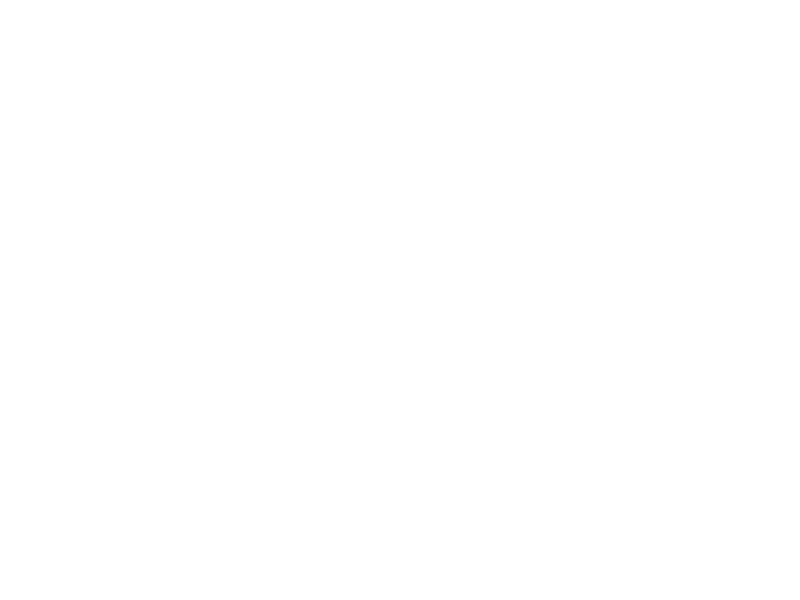

In [35]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

mink_idx = mink_df.set_index("word")

# month/day 좌표 추출
B_month = mink_idx.loc[months_in_vocab]["B"].values
H_month = mink_idx.loc[months_in_vocab]["H"].values
M_month = mink_idx.loc[months_in_vocab]["M"].values

B_day   = mink_idx.loc[days_in_vocab]["B"].values
H_day   = mink_idx.loc[days_in_vocab]["H"].values
M_day   = mink_idx.loc[days_in_vocab]["M"].values

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

# month / day 점
ax.scatter(B_month, H_month, M_month,
           c="teal", label="months", depthshade=True)
ax.scatter(B_day, H_day, M_day,
           c="purple", label="days", depthshade=True)

# 라벨링: month
for w in months_in_vocab:
    x = mink_idx.loc[w, "B"]
    y = mink_idx.loc[w, "H"]
    z = mink_idx.loc[w, "M"]
    ax.text(x, y, z, w[:3], color="teal", fontsize=8)

# 라벨링: day
for w in days_in_vocab:
    x = mink_idx.loc[w, "B"]
    y = mink_idx.loc[w, "H"]
    z = mink_idx.loc[w, "M"]
    ax.text(x, y, z, w[:3], color="purple", fontsize=8)

# month/day 중심 (M=0 평면에 표시)
ax.scatter(B_month_center, H_month_center, 0.0,
           c="teal", marker="X", s=150, label="month center")
ax.scatter(B_day_center, H_day_center, 0.0,
           c="purple", marker="X", s=150, label="day center")

# 축 범위는 month/day 주변으로만 제한
B_all = np.concatenate([B_month, B_day])
H_all = np.concatenate([H_month, H_day])
M_all = np.concatenate([M_month, M_day])

B_pad = (B_all.max() - B_all.min()) * 0.5 if B_all.max() > B_all.min() else 0.1
H_pad = (H_all.max() - H_all.min()) * 0.5 if H_all.max() > H_all.min() else 0.1
M_pad = (M_all.max() - M_all.min()) * 0.5 if M_all.max() > M_all.min() else 0.1

ax.set_xlim(B_all.min() - B_pad, B_all.max() + B_pad)
ax.set_ylim(H_all.min() - H_pad, H_all.max() + H_pad)
ax.set_zlim(M_all.min() - M_pad, M_all.max() + M_pad)

ax.set_xlabel("B (axis 2 coordinate)")
ax.set_ylabel("H (axis 1 coordinate)")
ax.set_zlabel("M (signed mass)")

ax.set_title("3D Minkowski Space (B, H, M) for Months and Days")
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

In [1]:
from sentence_transformers import SentenceTransformer
import numpy as np
import pandas as pd

# 1. Gemma 기반 sentence embedding 모델 로드
model = SentenceTransformer("Jaume/gemma-2b-embeddings")  # 2B 기반 [web:207]

# 2. vocab 정의: 전체 어휘 대신 일단 후보 단어 집합만
months = [
    "january","february","march","april","may","june",
    "july","august","september","october","november","december"
]
days = ["monday","tuesday","wednesday","thursday","friday","saturday","sunday"]

# plus: 실험용 일반 어휘 (common words) – 나중에 corpus에서 뽑아서 확장
candidate_words = months + days

# 3. 각 단어를 그대로 문장처럼 넣어서 임베딩
embs = model.encode(candidate_words, convert_to_numpy=True, normalize_embeddings=True)
V = np.array(embs)               # shape: (N, d)
words = np.array(candidate_words)

# 4. month/day 분리
idx = {w: i for i, w in enumerate(words)}
months_in_vocab = months
days_in_vocab = days

month_vecs = np.stack([V[idx[w]] for w in months_in_vocab])
day_vecs = np.stack([V[idx[w]] for w in days_in_vocab])

# 5. SVD 기반 직교 기저
X_cat = np.vstack([month_vecs, day_vecs])
U, S, Vt = np.linalg.svd(X_cat, full_matrices=False)
A = Vt                     # axes
alpha = V @ A.T            # spectral coordinates

# 6. Minkowski 좌표: H=alpha1, B=alpha2, M
H_vals = alpha[:, 0]
B_vals = alpha[:, 1]

c = 1.0
M2 = B_vals**2 - (c**2) * (H_vals**2)
M_vals = np.sign(M2) * np.sqrt(np.abs(M2))

mink_df = pd.DataFrame({
    "word": words,
    "H": H_vals,
    "B": B_vals,
    "M": M_vals,
})

# 7. Month/Day funnel 축 정의 (평균 벡터)
month_center = month_vecs.mean(axis=0)
month_center /= np.linalg.norm(month_center)

day_center = day_vecs.mean(axis=0)
day_center /= np.linalg.norm(day_center)

axis_month = month_center
axis_day = day_center

cos_month = V @ axis_month
cos_day = V @ axis_day

mink_df["cos_month"] = cos_month
mink_df["cos_day"] = cos_day

mink_df["depth_month"] = mink_df["cos_month"] * mink_df["H"] / (1.0 + np.abs(mink_df["M"]))
mink_df["depth_day"] = mink_df["cos_day"] * mink_df["H"] / (1.0 + np.abs(mink_df["M"]))

print(mink_df)

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

model-00001-of-00003.safetensors:   0%|          | 0.00/4.91G [00:00<?, ?B/s]

model-00002-of-00003.safetensors:   0%|          | 0.00/4.98G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/4.24M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

         word         H         B         M  cos_month   cos_day  depth_month  \
0     january -0.994098 -0.074915 -0.991271   0.994083  0.987110    -0.496274   
1    february -0.989186 -0.099926 -0.984126   0.988027  0.984169    -0.492581   
2       march -0.981834  0.046300 -0.980742   0.984207  0.971120    -0.487862   
3       april -0.987258  0.014448 -0.987152   0.990489  0.974906    -0.492095   
4         may -0.954594  0.202294 -0.932913   0.956563  0.945306    -0.472411   
5        june -0.987994  0.009811 -0.987945   0.991043  0.975942    -0.492541   
6        july -0.996313  0.002608 -0.996310   0.997202  0.987941    -0.497681   
7      august -0.984458  0.060256 -0.982612   0.988026  0.971657    -0.490600   
8   september -0.995792 -0.038645 -0.995042   0.996783  0.987130    -0.497528   
9     october -0.995972 -0.039230 -0.995199   0.996592  0.987953    -0.497483   
10   november -0.994779 -0.023901 -0.994491   0.995978  0.985797    -0.496757   
11   december -0.995404 -0.0

In [3]:
print(mink_df.to_markdown(index=False))

| word      |         H |           B |         M |   cos_month |   cos_day |   depth_month |   depth_day |
|:----------|----------:|------------:|----------:|------------:|----------:|--------------:|------------:|
| january   | -0.994098 | -0.0749147  | -0.991271 |    0.994083 |  0.98711  |     -0.496274 |   -0.492793 |
| february  | -0.989186 | -0.0999258  | -0.984126 |    0.988027 |  0.984169 |     -0.492581 |   -0.490658 |
| march     | -0.981834 |  0.0463005  | -0.980742 |    0.984207 |  0.97112  |     -0.487862 |   -0.481374 |
| april     | -0.987258 |  0.014448   | -0.987152 |    0.990489 |  0.974906 |     -0.492095 |   -0.484353 |
| may       | -0.954594 |  0.202294   | -0.932913 |    0.956563 |  0.945306 |     -0.472411 |   -0.466852 |
| june      | -0.987994 |  0.00981091 | -0.987945 |    0.991043 |  0.975942 |     -0.492541 |   -0.485036 |
| july      | -0.996313 |  0.00260772 | -0.99631  |    0.997202 |  0.987941 |     -0.497681 |   -0.493059 |
| august    | -0.984458 |  0